## **The Lottery Ticket Hypothesis (A Simple Coding Tutorial)**

**Paper:** *"The Lottery Ticket Hypothesis: Finding Sparse, Trainable Neural Networks"*  
**Authors:** Jonathan Frankle & Michael Carbin (2019)


### **What are we building?**

For this code tutorial, we will show intuitively, with simple code, that:

> A large neural network contains specific, smaller **subnetworks**, that were already capable of learning well from the very start.

We call this subnetwork the **winning ticket**.

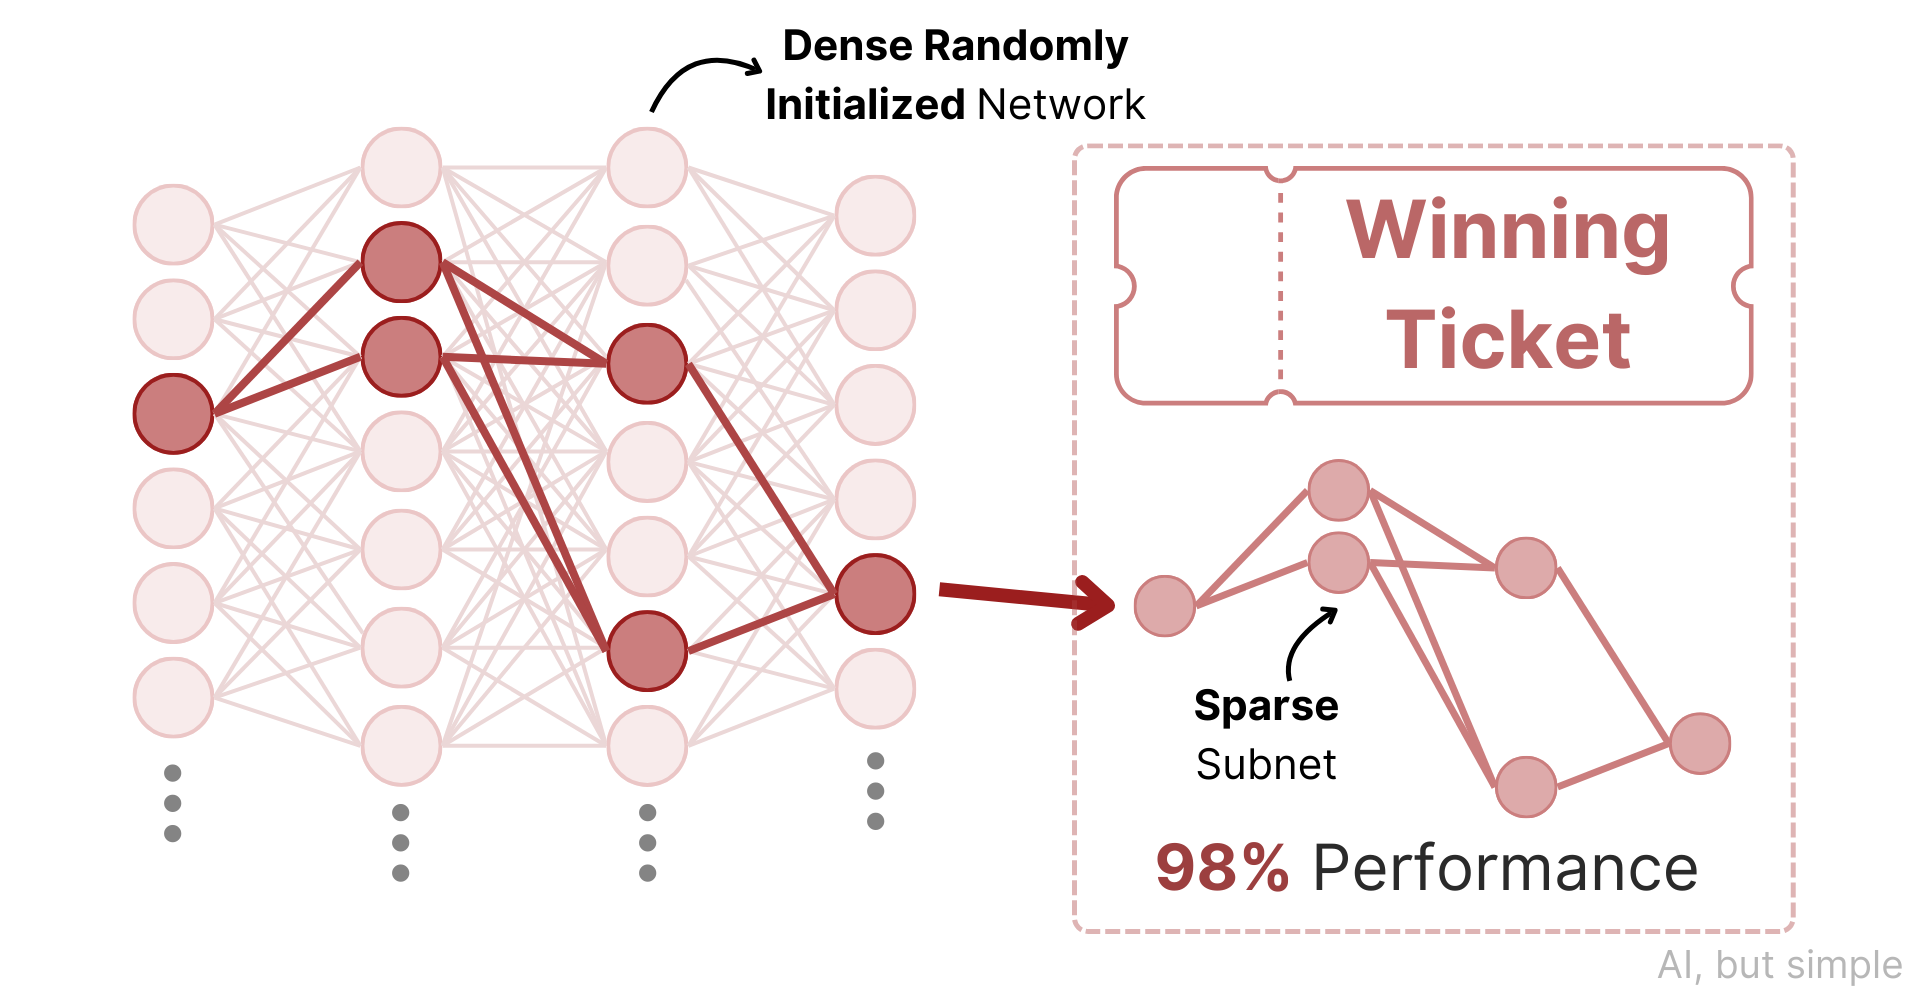

Here's what we will do in this tutorial:

1. Build a simple neural network
2. Train it on a toy problem
3. **Prune** (remove) small weights
4. Reset remaining weights to their **original** values
5. Retrain and compare (did the small network keep up?)



## Step 1 - Imports & Setup


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import copy

# Fix the random seed so results are reproducible
np.random.seed(0)

## Step 2 - Create a Toy Dataset

We need something to *learn* so let's use a simple dataset:

- **Input:** 10 numbers (features)
- **Output:** 1 or 0 (binary classification)
- **Rule:** the answer depends only on the **first 2 features** (the rest are noise)

This mimics real life: most inputs have a lot of irrelevant information and a good network should learn to focus on what matters.

In [ ]:
N = 1000         # number of data points
INPUT_DIM = 10   # number of input features

# Random input data
X = np.random.randn(N, INPUT_DIM)

# Label = 1 if (feature_0 + feature_1) > 0, else 0
# Only the first 2 features actually matter!
y = (X[:, 0] + X[:, 1] > 0).astype(float).reshape(-1, 1)

# Split into train / test
X_train, y_train = X[:240], y[:240]
X_test,  y_test  = X[240:], y[240:]

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Label balance    : {y_train.mean():.2f} (should be ~0.5)")

## Step 3 - Build a Simple Neural Network

To keep things simple we'll make a **2-layer network** (also called a single hidden layer MLP):

```
Input (10)  →  Hidden layer (32 neurons)  →  Output (1)
```

The **weights** are the numbers the network learns.  
The **mask** is a 0/1 grid that tells us which weights are *active* (1) or *pruned* (0).

Think of the mask like a stencil. It hides certain weights so the network ignores them.

In [ ]:
HIDDEN = 32   # number of neurons in the hidden layer

def init_network():
    """Create a fresh network with random weights."""
    params = {
        'W1': np.random.randn(INPUT_DIM, HIDDEN) * 0.1,  # layer 1 weights
        'b1': np.zeros(HIDDEN),                           # layer 1 biases
        'W2': np.random.randn(HIDDEN, 1) * 0.1,          # layer 2 weights
        'b2': np.zeros(1),                                # layer 2 bias
    }
    return params

def init_mask(params):
    """All-ones mask = nothing pruned yet."""
    return {k: np.ones_like(v) for k, v in params.items()}

# Let's see what the shapes look like
p = init_network()
print("Weight shapes:")
for name, arr in p.items():
    print(f"  {name}: {arr.shape}")

total_weights = sum(v.size for v in p.values())
print(f"\nTotal parameters: {total_weights}")

## Step 4 - Forward Pass

So now we: *feed data in, get a prediction out*.

Here's what happens:
1. Multiply inputs by W1, add bias b1 → hidden layer
2. Apply **ReLU**: replace negatives with 0 (adds non-linearity)
3. Multiply by W2, add bias b2 → raw output
4. Apply **Sigmoid**: squash to range [0, 1] → probability

The mask is applied by *multiplying* weights with it and zeroed-out weights contribute nothing.

In [ ]:
def relu(x):
    """ReLU: keeps positive values, zeros out negatives."""
    return np.maximum(0, x)

def sigmoid(x):
    """Sigmoid: squashes any number into (0, 1)."""
    return 1 / (1 + np.exp(-x))

def forward(params, mask, X):
    """Run a forward pass. Returns prediction + intermediate values."""

    # Apply mask: pruned weights become zero
    W1 = params['W1'] * mask['W1']
    b1 = params['b1'] * mask['b1']
    W2 = params['W2'] * mask['W2']
    b2 = params['b2'] * mask['b2']

    z1   = X @ W1 + b1          # hidden pre-activation
    a1   = relu(z1)             # hidden activation
    z2   = a1 @ W2 + b2         # output pre-activation
    pred = sigmoid(z2)          # final probability

    return pred, a1, z1         # return extras for backprop

# Quick test
params = init_network()
mask   = init_mask(params)
pred, _, _ = forward(params, mask, X_train[:5])
print("Predictions for first 5 samples (untrained, should be ~0.5):")
print(pred.flatten().round(3))

## Step 5 - Loss Function & Accuracy

We need a way to measure **how wrong** the network is.

We use **Binary Cross-Entropy (BCE)** — standard for yes/no problems:
- Low loss = predictions are close to true labels
- High loss = predictions are far off

In [ ]:
def bce_loss(pred, y_true):
    """Binary cross-entropy loss."""
    eps = 1e-8   # small number to avoid log(0)
    return -np.mean(
        y_true * np.log(pred + eps) +
        (1 - y_true) * np.log(1 - pred + eps)
    )

def accuracy(params, mask, X, y):
    pred, _, _ = forward(params, mask, X)
    predicted_class = (pred > 0.5).astype(float)
    return np.mean(predicted_class == y)

# Test on untrained network
loss_before = bce_loss(pred, y_train[:5])
print(f"Loss before training: {loss_before:.4f}")

## Step 6 - Training with Gradient Descent

Training means adjusting weights to reduce the loss. We use **Stochastic Gradient Descent (SGD)**:

```
weight = weight - learning_rate x gradient
```

The gradient tells us: *which direction makes the loss go up?*  
We move in the **opposite** direction.

The mask matters here because we **skip** gradient updates for pruned weights.

In [ ]:
def train(params, mask, X, y, epochs=300, lr=0.05, verbose=True):
    """
    Train the network using SGD.
    Returns updated params and loss history.
    """
    losses = []

    for epoch in range(epochs):

        # --- Forward pass ---
        pred, a1, z1 = forward(params, mask, X)
        loss = bce_loss(pred, y)
        losses.append(loss)

        # --- Backward pass (gradients by chain rule) ---
        n = len(y)
        d_pred = (pred - y) / n           # gradient of loss w.r.t. prediction

        # Layer 2 gradients
        dW2 = a1.T @ d_pred
        db2 = d_pred.sum(axis=0)

        # Backprop through layer 2 and ReLU
        d_a1 = d_pred @ params['W2'].T
        d_z1 = d_a1 * (z1 > 0)           # ReLU gradient: 0 where z1 was negative

        # Layer 1 gradients
        dW1 = X.T @ d_z1
        db1 = d_z1.sum(axis=0)

        # --- Update weights (only where mask = 1) ---
        params['W1'] -= lr * dW1 * mask['W1']   # pruned weights stay at 0
        params['b1'] -= lr * db1 * mask['b1']
        params['W2'] -= lr * dW2 * mask['W2']
        params['b2'] -= lr * db2 * mask['b2']

        if verbose and (epoch + 1) % 100 == 0:
            acc = accuracy(params, mask, X, y)
            print(f"Epoch {epoch+1:3d} | Loss: {loss:.4f} | Acc: {acc:.2%}")

    return params, losses

## Step 7 - Train the Full Network (Baseline)

Before any pruning, we train the full network and save its **original weights** (θ₀).  
These initial weights are the *lottery tickets* and we'll need them later!

In [ ]:
# Initialize network
params = init_network()
mask   = init_mask(params)

# Save the original weights BEFORE training — this is theta_0
theta_0 = copy.deepcopy(params)

print("Training Full Network: ")
params, full_losses = train(params, mask, X_train, y_train, epochs=300)

full_train_acc = accuracy(params, mask, X_train, y_train)
full_test_acc  = accuracy(params, mask, X_test,  y_test)

print(f"\nFull network - Train acc: {full_train_acc:.2%} | Test acc: {full_test_acc:.2%}")

## Step 8 - Pruning: Remove Small Weights

After training, many weights end up very close to **zero** and they contribute almost nothing.

**Magnitude pruning** simply removes the weights with the smallest absolute values.

```
if |weight| < threshold:
    mask = 0   # prune it
```

We keep the **structure** of the pruned network but throw away the unimportant weights.

In [ ]:
def prune(params, mask, prune_percent=20):
    """
    Only looks at weights that are currently active (mask = 1).
    """
    new_mask = copy.deepcopy(mask)

    for key in ['W1', 'W2']:   # prune weight matrices (not biases)
        # Collect magnitudes of active weights only
        active = np.abs(params[key][mask[key] == 1])

        # Find the threshold value
        threshold = np.percentile(active, prune_percent)

        # Set mask to 0 wherever weight is below threshold AND currently active
        new_mask[key] = np.where(
            (np.abs(params[key]) <= threshold) & (mask[key] == 1),
            0,           # prune
            mask[key]    # keep
        )

    return new_mask

def sparsity(mask):
    """What fraction of weights are pruned?"""
    total  = sum(v.size for v in mask.values())
    pruned = sum((v == 0).sum() for v in mask.values())
    return pruned / total

# Test: prune 80% of the trained network
test_mask = prune(params, mask, prune_percent=80)
print(f"Sparsity after pruning 80%: {sparsity(test_mask):.1%}")
print("(Some % is lower than 80 because biases are not pruned)")

You can retry the code by changing the line 29, i.e. changing the prune percentage and looking at the new results!

## Step 9 - The Winning Ticket: Reset & Retrain

This is the **core idea** of the paper.

After pruning, instead of continuing with the trained weights, we:

1. Keep the **mask** (the pruning pattern we just found)
2. Reset surviving weights back to their **original random values** (θ₀)
3. Train **from scratch** again

If this small network trains just as well as the full one -> we found a **winning ticket**!

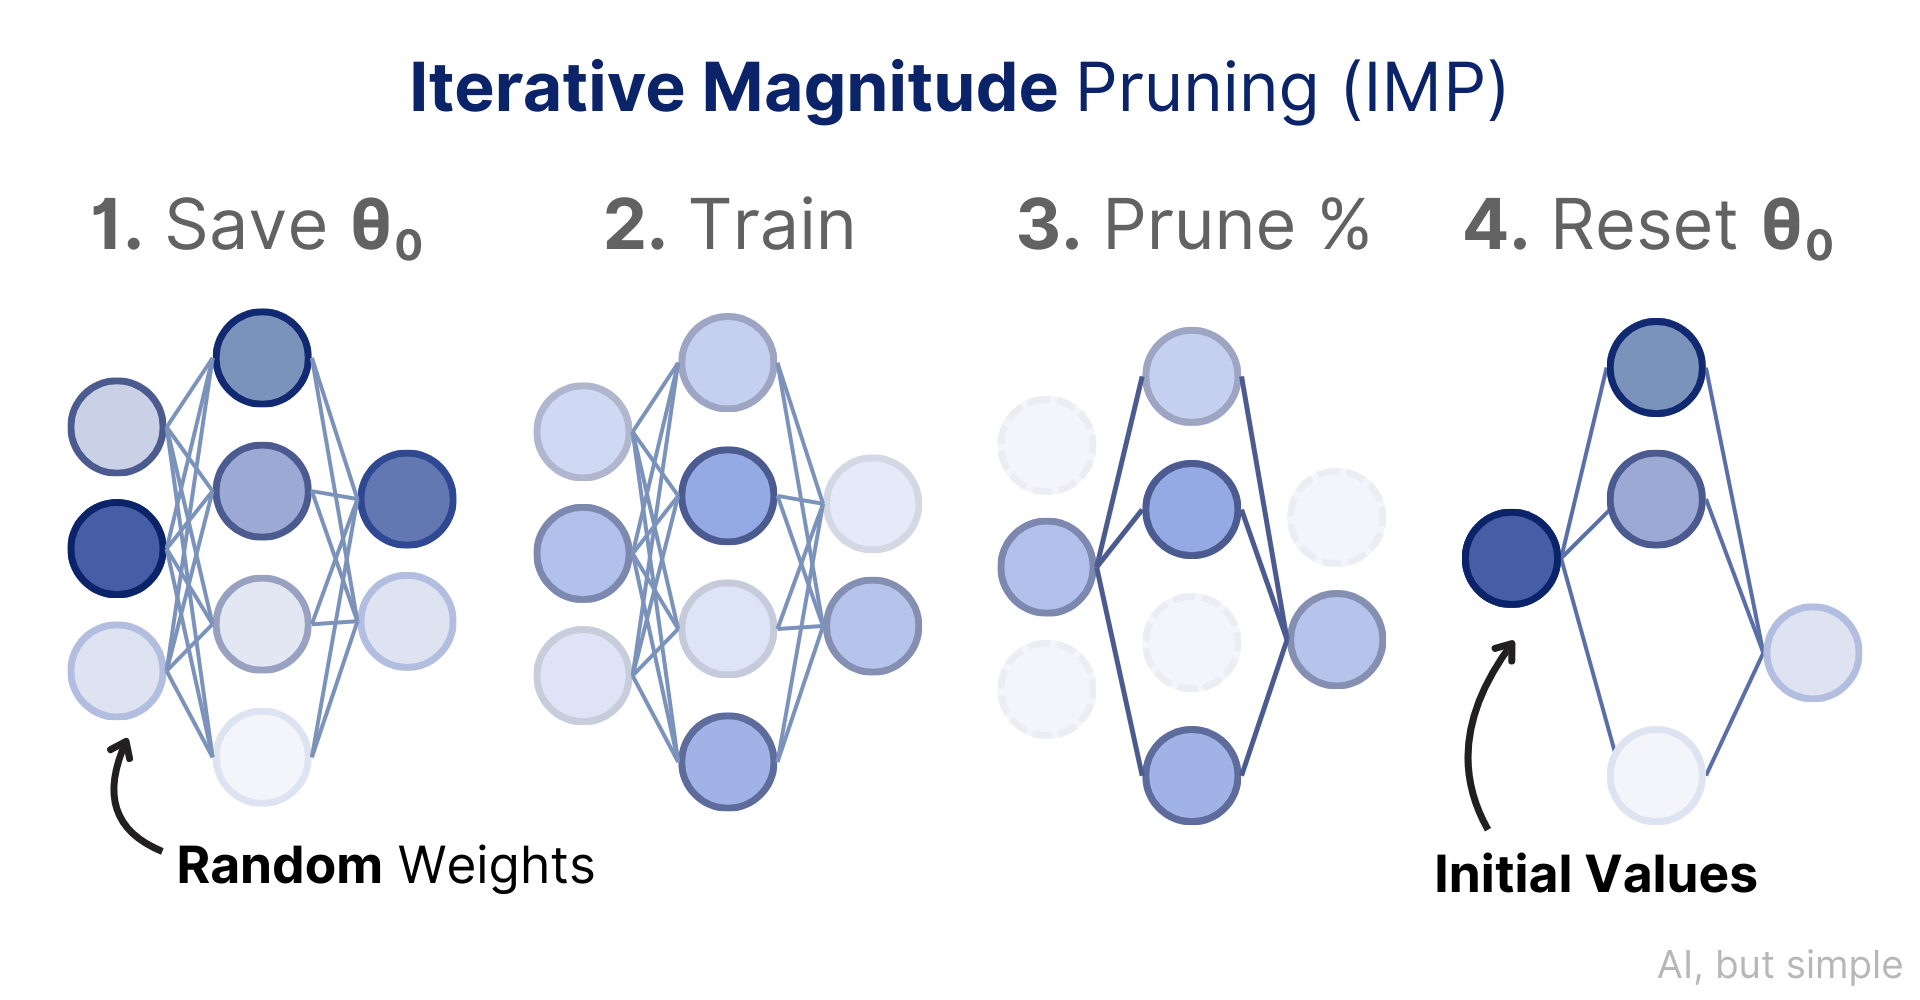

In [ ]:
# Step 1: Prune the trained network
winning_mask = prune(params, mask, prune_percent=80)
print(f"Winning ticket sparsity: {sparsity(winning_mask):.1%}")

# Step 2: Reset weights to ORIGINAL values (theta_0) — NOT random new ones!
ticket_params = {k: theta_0[k] * winning_mask[k] for k in theta_0}

# Step 3: Train the sparse network from its original init
print("Training Winning Ticket...")
ticket_params, ticket_losses = train(
    ticket_params, winning_mask, X_train, y_train, epochs=300
)

ticket_train_acc = accuracy(ticket_params, winning_mask, X_train, y_train)
ticket_test_acc  = accuracy(ticket_params, winning_mask, X_test,  y_test)
print(f"WT Train acc: {ticket_train_acc:.2%} | WT Test acc: {ticket_test_acc:.2%}")


## Step 10 - What if we use Random Init?

The paper makes an important claim: the **original initialization** is essential.  
If you use the same pruned structure but **fresh random weights**, it won't work as well.

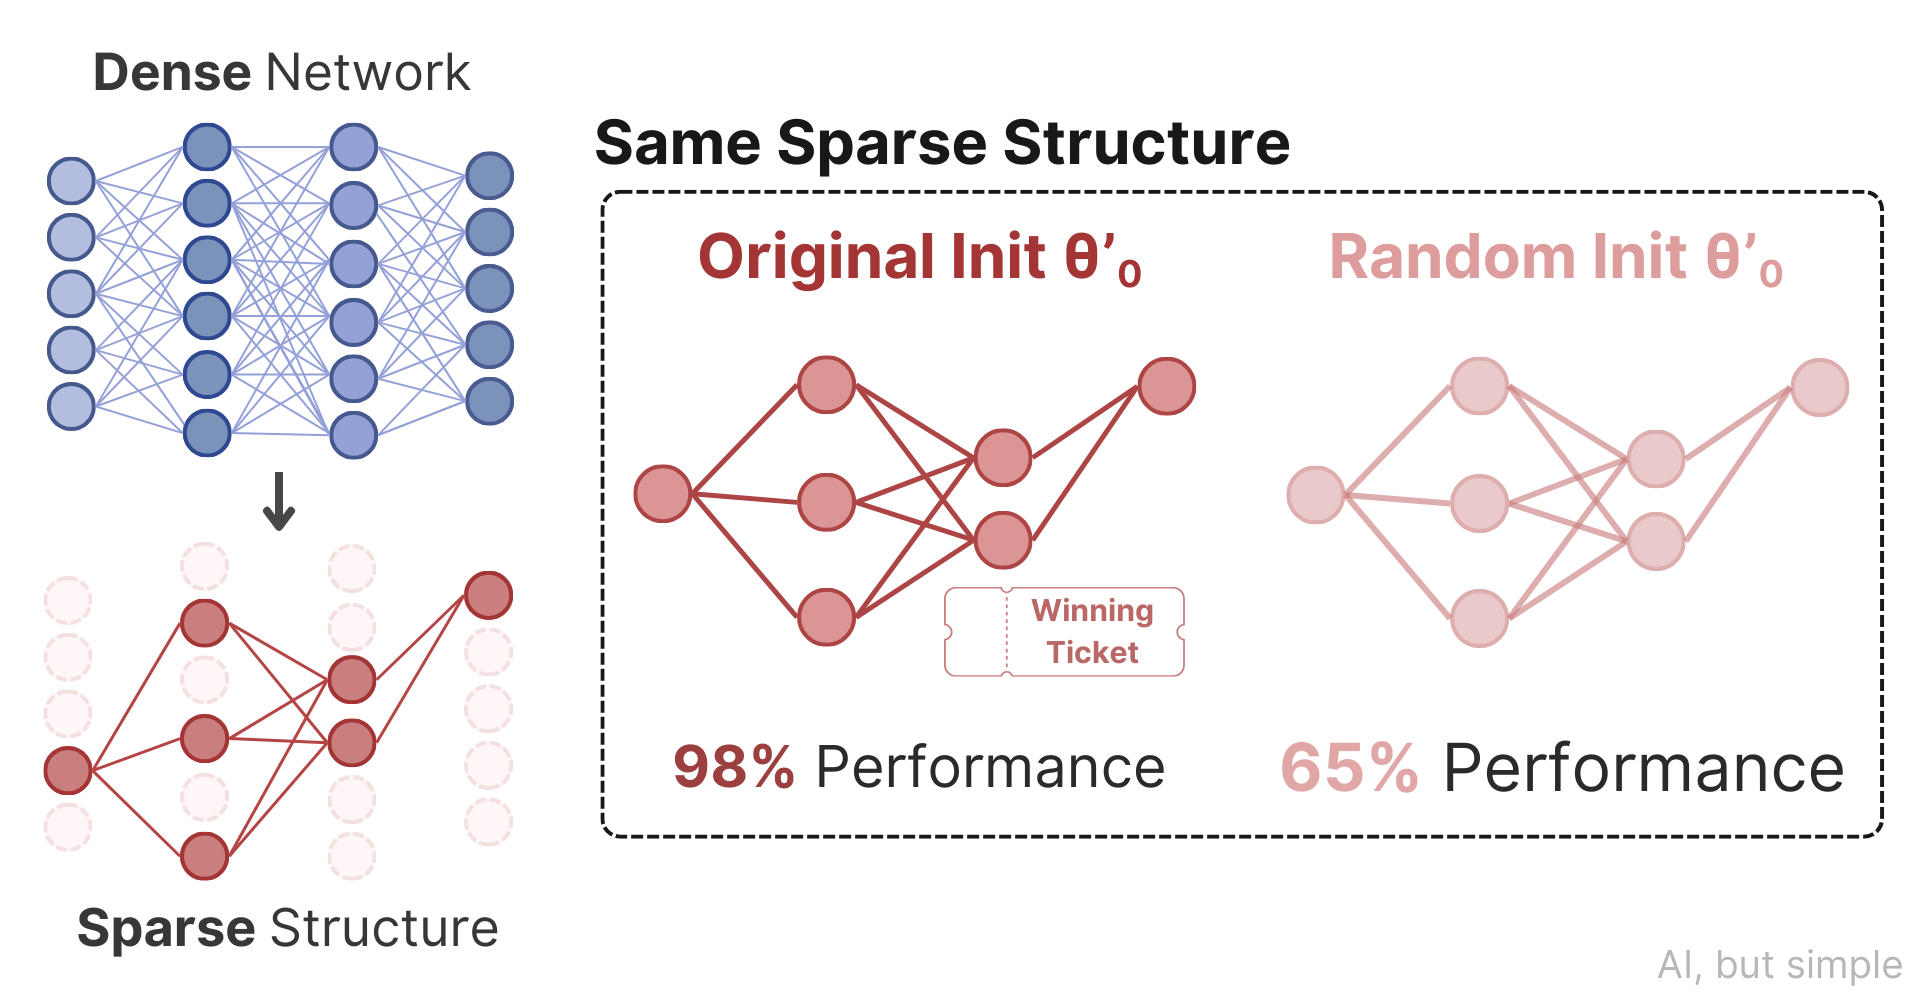

Let's test this.

In [ ]:
# Same mask, but new random weights (NOT theta_0)
reinit_params = init_network()   # completely new random initialization
reinit_params = {k: reinit_params[k] * winning_mask[k] for k in reinit_params}

print("=== Training Same Structure, Random Init ===")
reinit_params, reinit_losses = train(
    reinit_params, winning_mask, X_train, y_train, epochs=300
)

reinit_train_acc = accuracy(reinit_params, winning_mask, X_train, y_train)
reinit_test_acc  = accuracy(reinit_params, winning_mask, X_test,  y_test)
print(f"\nRandom reinit - Train acc: {reinit_train_acc:.2%} | Test acc: {reinit_test_acc:.2%}")

If you run the above cell multiple times, you will notice that the train accuracy changes and loses the higgher accuracy it first had!

## Step 11 - Results: Side-by-Side Comparison

Now let's compare all three and plot the loss curves.

In [ ]:
print("-" * 50)
print("RESULTS SUMMARY")
print("-" * 50)
print(f"Full Network, {int((1-sparsity(mask))*100):3d}% active weights | Test acc: {full_test_acc:.2%}")
print(f"Winning Ticket, {int((1-sparsity(winning_mask))*100):3d}% active weights | Test acc: {ticket_test_acc:.2%} (sparse + original init)")
print(f"Random Reinit, {int((1-sparsity(winning_mask))*100):3d}% active weights | Test acc: {reinit_test_acc:.2%}  (sparse + new random init)")
print("-" * 50)
print()

The key insight is that the initialization matters, not only the structure of the neural network. The winning ticket's test accuracy is comparble to the full network, while a random reinitialization has considerably lower test accuracy.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# fig.suptitle('Lottery Ticket Hypothesis Results', fontsize=14, fontweight='bold')

# Left: Loss curves
ax = axes[0]
ax.plot(full_losses,   color='steelblue', lw=2, label='Full network (all weights)')
ax.plot(ticket_losses, color='seagreen',  lw=2, label='Winning ticket (pruned + θ₀ reset)')
ax.plot(reinit_losses, color='tomato',    lw=2, label='Random reinit (pruned + new init)',
        linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: Bar chart
ax = axes[1]
labels = ['Full Network', 'Winning Ticket\n(sparse + θ₀)', 'Random Reinit\n(sparse + new init)']
values = [full_test_acc, ticket_test_acc, reinit_test_acc]
colors = ['steelblue', 'seagreen', 'tomato']
bars   = ax.bar(labels, [v * 100 for v in values], color=colors,
                edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1%}', ha='center', fontweight='bold', fontsize=11)

ax.set_ylim(50, 105)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Final Test Accuracy Comparison')
ax.grid(True, axis='y', alpha=0.3)

'''
plt.tight_layout()
plt.savefig('lottery_ticket_results.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved as lottery_ticket_results.png")
'''

## Step 12 - Iterative Pruning

The paper actually prunes **iteratively** - a little at a time over many rounds.  
This finds sparser networks than one-shot pruning.

Each round:
1. Train -> Prune 20% -> Reset to θ₀ -> repeat

Let's watch what happens to accuracy as sparsity grows.

In [ ]:
# Fresh start
params_imp = init_network()
theta_0_imp = copy.deepcopy(params_imp)
mask_imp    = init_mask(params_imp)

history = []   # track (sparsity, test_accuracy) per round

ROUNDS = 6
print(f"Running {ROUNDS} rounds of IMP (each: train 200 epochs, prune 20%)\n")

for round_num in range(ROUNDS):
    # 1. Train
    params_imp, _ = train(
        params_imp, mask_imp, X_train, y_train,
        epochs=200, verbose=False
    )

    # 2. Evaluate
    test_acc = accuracy(params_imp, mask_imp, X_test, y_test)
    sp = sparsity(mask_imp)
    history.append((sp, test_acc))
    print(f"Round {round_num+1} | Sparsity: {sp:.1%} | Test acc: {test_acc:.2%}")

    # 3. Prune
    mask_imp = prune(params_imp, mask_imp, prune_percent=20)

    # 4. Reset to original weights (winning ticket step)
    params_imp = {k: theta_0_imp[k] * mask_imp[k] for k in theta_0_imp}

In [ ]:
sparsities = [h[0] * 100 for h in history]
accuracies = [h[1] * 100 for h in history]

plt.figure(figsize=(7, 4))
plt.plot(sparsities, accuracies, 'o-', color='seagreen', linewidth=2, markersize=8)
plt.axhline(y=full_test_acc * 100, color='steelblue', linestyle='--',
            label=f'Full network baseline ({full_test_acc:.1%})')

# Annotate each point
for sp, acc in zip(sparsities, accuracies):
    plt.annotate(f'{acc:.1f}%', (sp, acc), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=9)

plt.xlabel('Sparsity (% weights pruned)')
plt.ylabel('Test Accuracy (%)')
plt.title('Iterative Magnitude Pruning — Sparsity vs Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('imp_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nKey takeaway: accuracy stays high even as we remove more and more weights.")
print("The winning ticket is small but large and accurate!")

## Conclusion

Here's everything we learned and coded:

| Concept | What we did |
|---------|-------------|
| **Full network** | Built and trained a 2-layer MLP from scratch |
| **Pruning** | Removed the smallest-magnitude weights using a binary mask |
| **Winning ticket** | Reset surviving weights to original θ₀ and retrained |
| **Initialization** | Proved the *initialization* matters - not just the structure |
| **IMP Algorith** | Repeated prune -> reset -> retrain over multiple rounds |

### The main insight:

> A large network is a search space. SGD finds one of many small subnetworks that was already set up to win - after training.

### Experiment further!

- Try **higher prune ratios** (50%, 70%) - and look at what point does the ticket lose?
- Try **more IMP rounds** - how sparse can you go?